### Import necessary libraries & Datasets

In [1]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import dask.dataframe as dd
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [2]:
songs_data_path = 'A:/CODES/PROJECTS/hybrid-recommender-system/data/raw/Music Info.csv'
songs_df = pd.read_csv(songs_data_path, usecols=["track_id", "name", "artist", "spotify_preview_url"])
songs_df.head()

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...


In [3]:
users_data_path = 'A:/CODES/PROJECTS/hybrid-recommender-system/data/raw/User Listening History.csv'
df = dd.read_csv(users_data_path)
df.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


### Preparing & playing with dask

In [4]:
# No data will show until compute is called as Dask uses chunking and only store metadata.
df

# This will load the entire dataset into the memory
# df.compute()

,track_id,user_id,playcount
npartitions=9,,,
,string,string,int64
,...,...,...
...,...,...,...
,...,...,...
,...,...,...


In [5]:
# Number of partitions/chunks created by Dask
df.npartitions

9

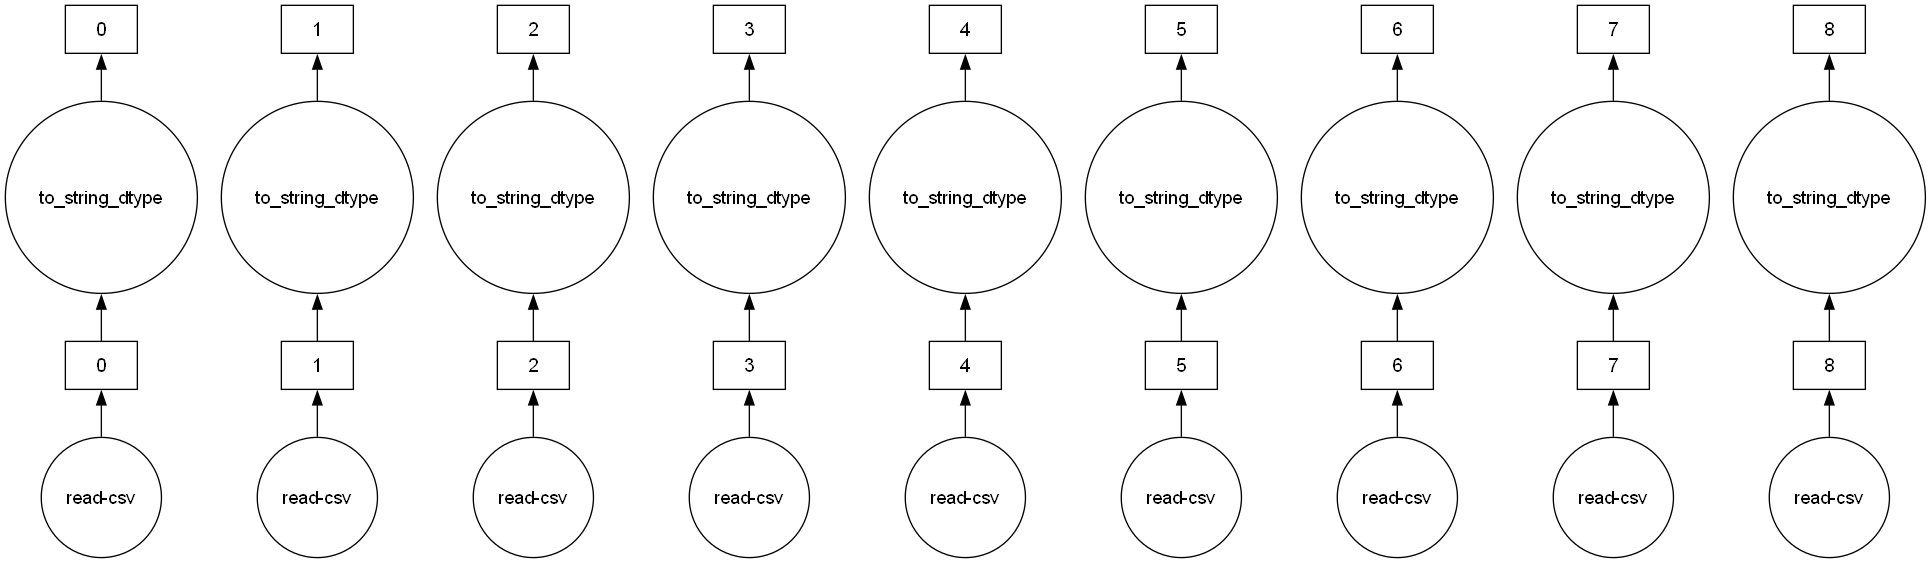

In [6]:
# Make sure you have https://graphviz.org/download/ installed and added to your system's PATH for this to work.
# This will show the task/chunk graph created by Dask
df.visualize(tasks=True)

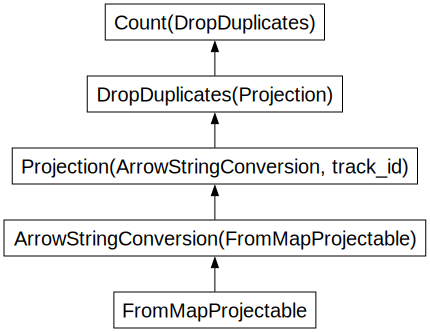

In [7]:
# number of unique tracks in the data

unique_tracks = df.loc[:, "track_id"].nunique()
unique_tracks.visualize()

In [8]:
# This will not show the actual number until compute is called
unique_tracks

<dask_expr.expr.Scalar: expr=(DropDuplicates(frame=ArrowStringConversion(frame=FromMapProjectable(e2f42ca))['track_id'], split_every=False)).count(), dtype=int64>

In [9]:
unique_tracks = unique_tracks.compute()
print(f"Number of unique tracks: {unique_tracks}")

Number of unique tracks: 30459


In [10]:
# number of unique users in the data

unique_users = df.loc[:, "user_id"].nunique().compute()
unique_users

np.int64(962037)

In [11]:
# list of unique track_ids

unique_track_ids = df.loc[:, "track_id"].unique().compute().tolist()
len(unique_track_ids)

30459

In [12]:
# filtered songs out of the songs_df that are present in the unique_track_ids list

filtered_songs = songs_df[songs_df["track_id"].isin(unique_track_ids)]
filtered_songs.reset_index(drop=True, inplace=True)
filtered_songs

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
3,TRXOGZT128F424AD74,Karma Police,Radiohead,https://p.scdn.co/mp3-preview/5a09f5390e2862af...
4,TRUJIIV12903CA8848,Clocks,Coldplay,https://p.scdn.co/mp3-preview/24c7fe858b234e3c...
...,...,...,...,...
30454,TRXWSIN128F9339A11,Infinite Love Song,Maximilian Hecker,https://p.scdn.co/mp3-preview/8b3d529025fe3c60...
30455,TRPIGDW12903CDEB2D,Slip of the Lip,Fact,https://p.scdn.co/mp3-preview/cf64490291f9a600...
30456,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...
30457,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...


In [13]:
filtered_songs[filtered_songs["name"] == "Crazy in Love"]

,track_id,name,artist,spotify_preview_url
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...


### Interaction Matrix

In [14]:
# We use index and column as interger using categorize as it use less memory and faster to compute

df = dd.read_csv(users_data_path)

# change playcount to float64
df['playcount'] = df['playcount'].astype(np.float64)

# categorize user_id and track_id columns : one category created only once and all instances use this
df = df.categorize(columns=['user_id', 'track_id'])

# Convert user_id and track_id to numeric indices
user_mapping = df['user_id'].cat.codes
track_mapping = df['track_id'].cat.codes
df = df.assign(user_idx=user_mapping, track_idx=track_mapping)

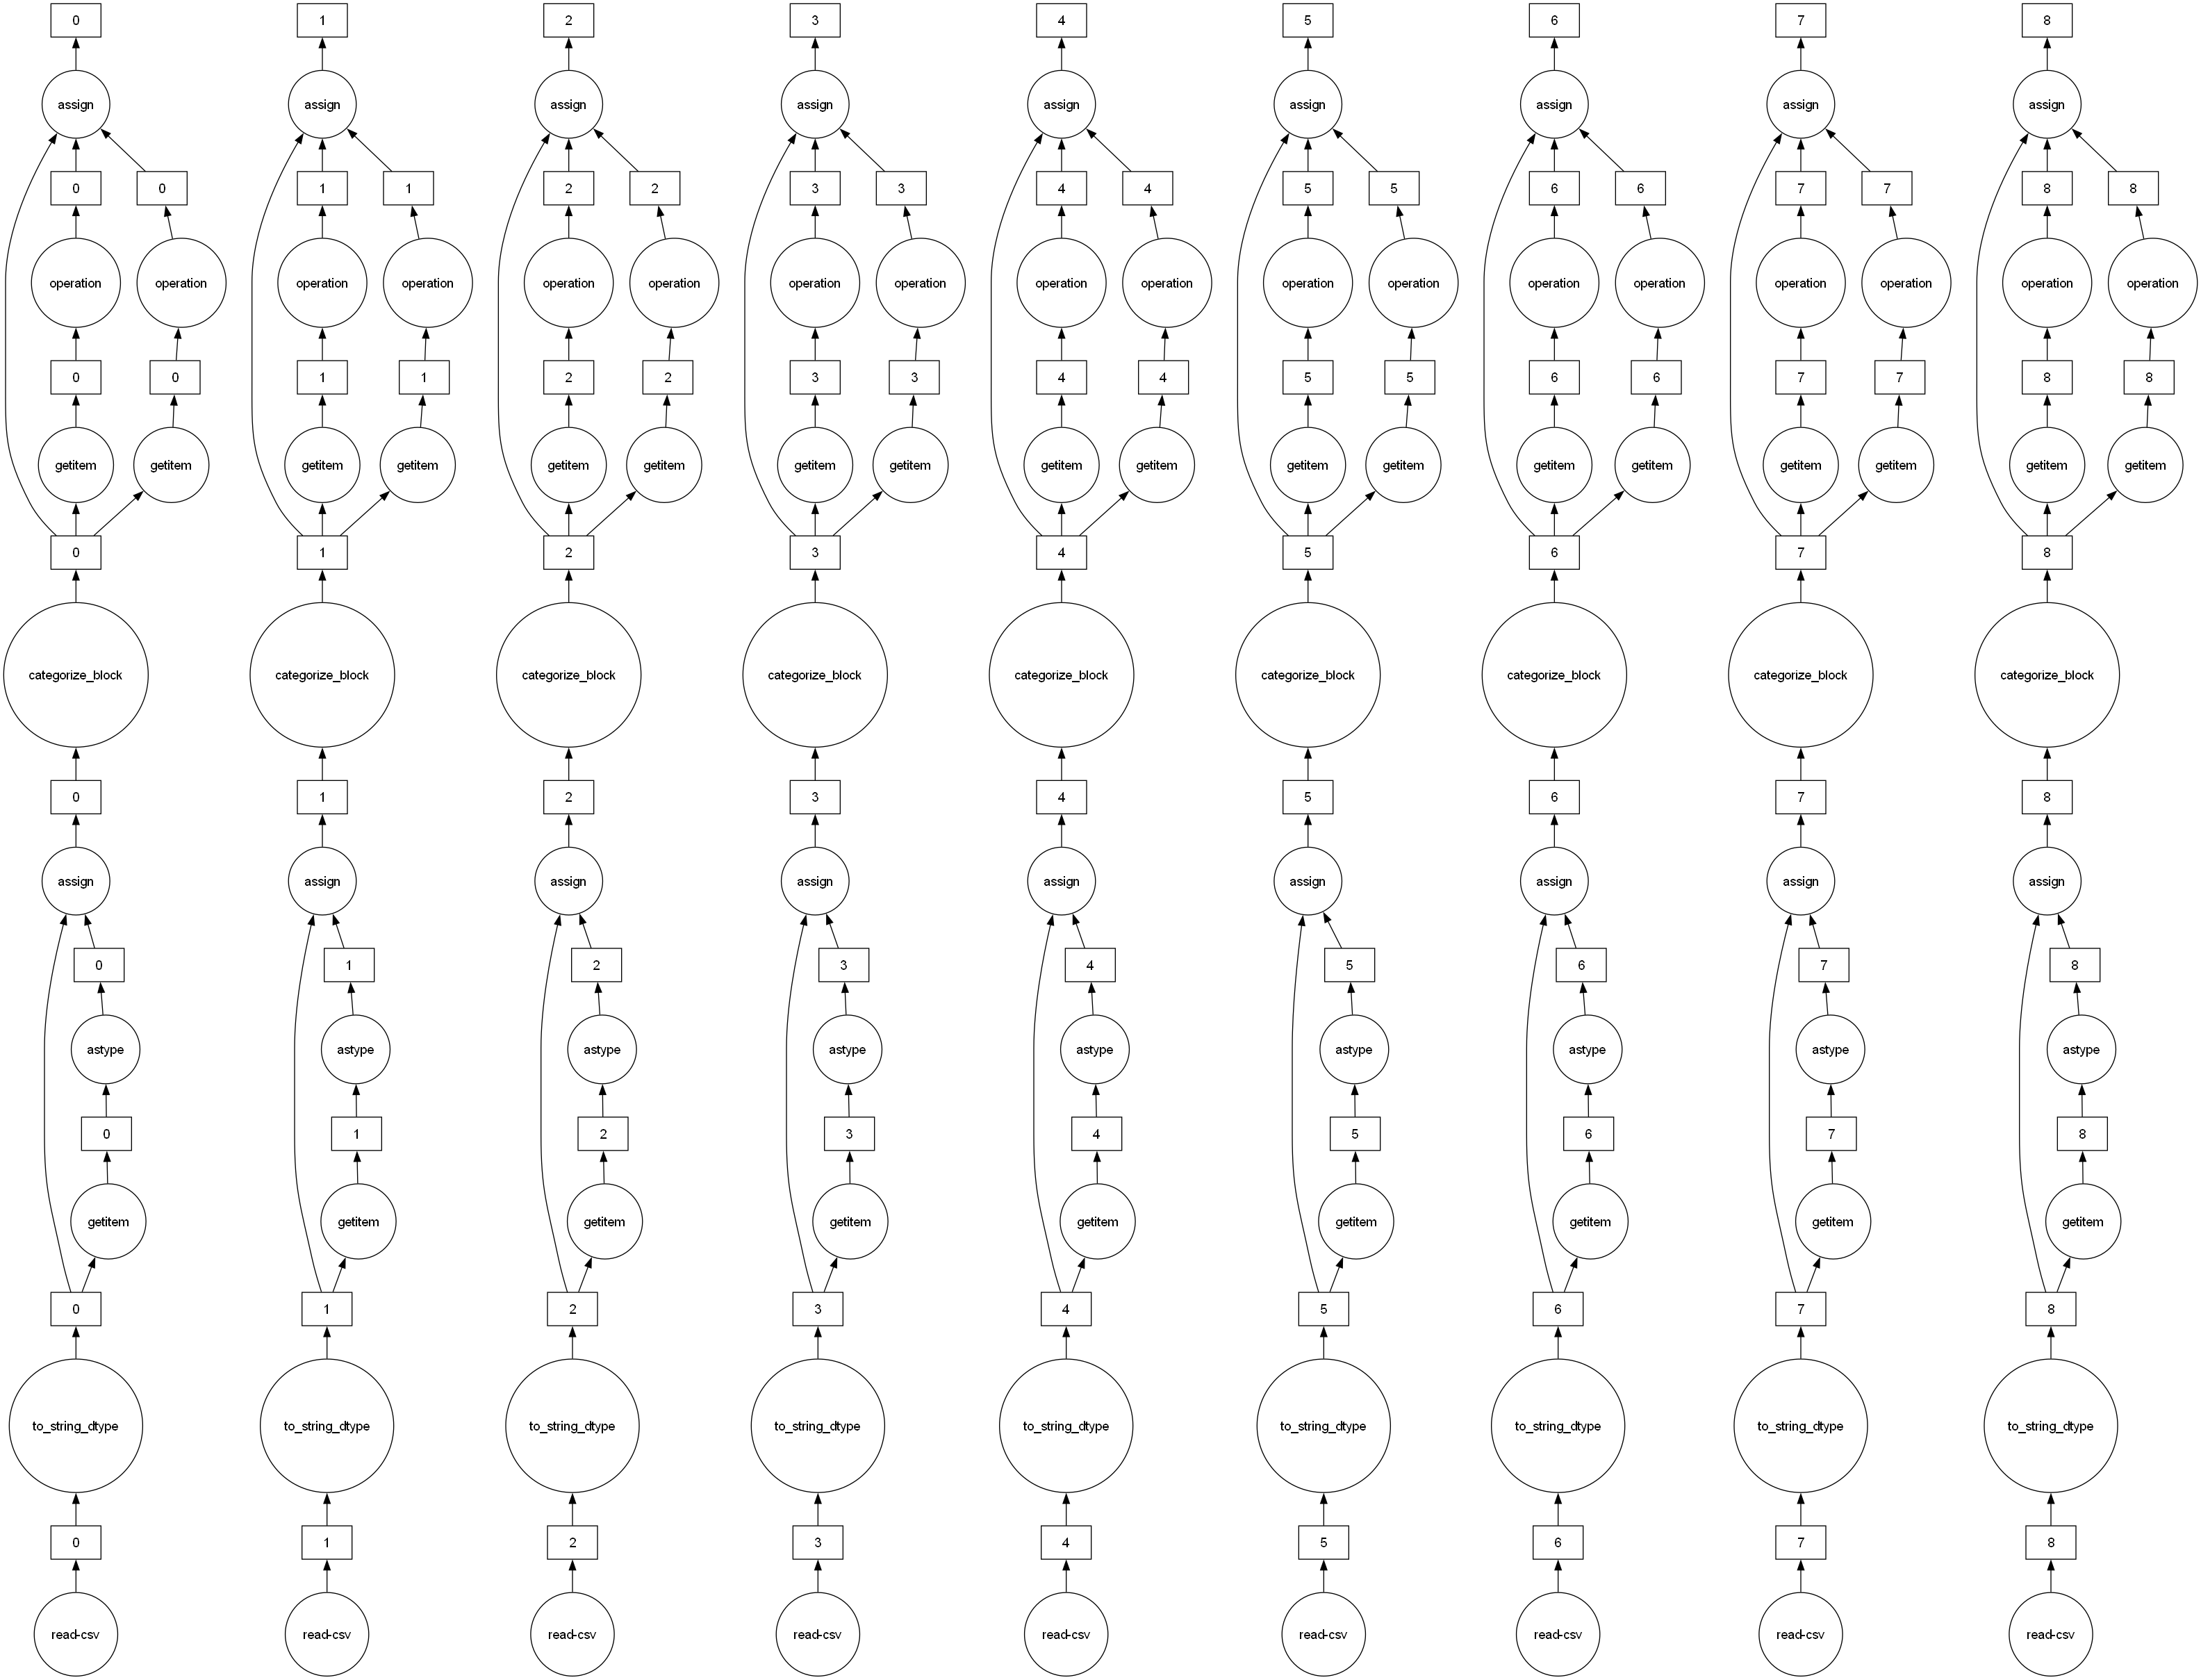

In [15]:
# visualization for each chuck seperately
df.visualize(tasks=True)

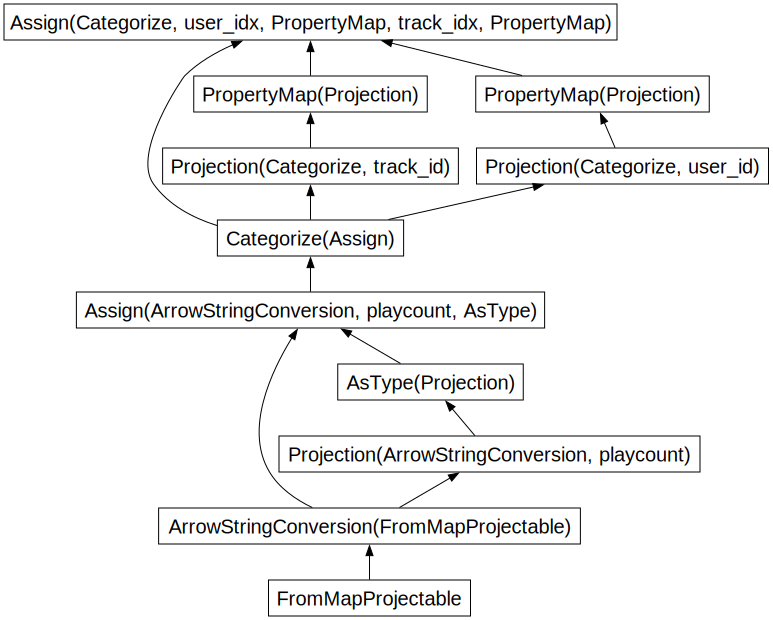

In [16]:
df.visualize()

In [17]:
df

,track_id,user_id,playcount,user_idx,track_idx
npartitions=9,,,,,
,category[known],category[known],float64,int32,int16
,...,...,...,...,...
...,...,...,...,...,...
,...,...,...,...,...
,...,...,...,...,...


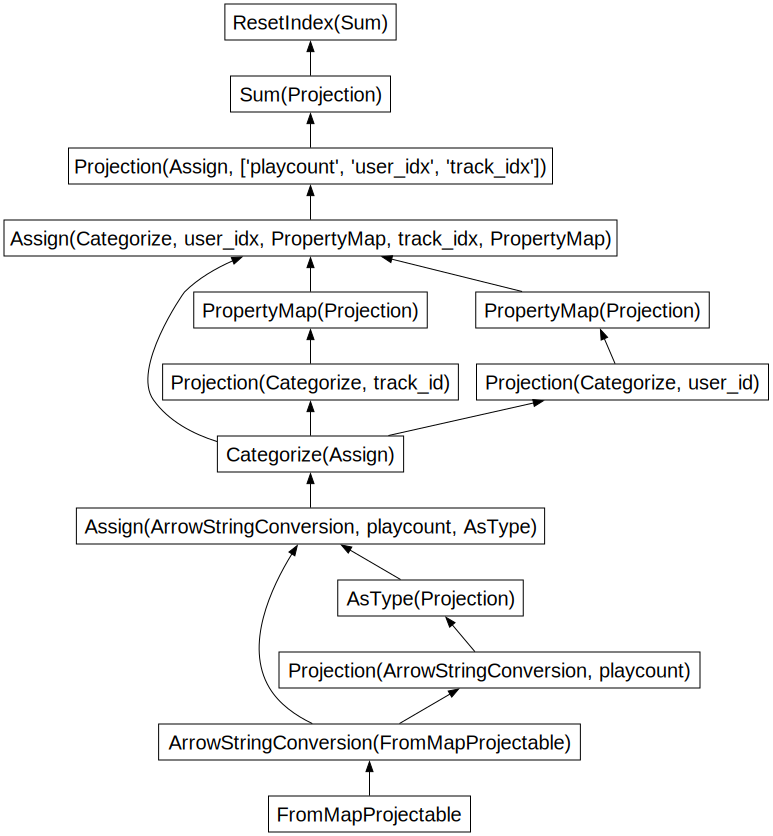

In [18]:
# Dask doesn't support pivot tables directly, so we aggregate manually
interaction_array = df.groupby(['track_idx', 'user_idx'])['playcount'].sum().reset_index()
interaction_array.visualize()

In [19]:
interaction_array

,track_idx,user_idx,playcount
npartitions=1,,,
,int16,int32,float64
,...,...,...


In [20]:
interaction_array = interaction_array.compute()
interaction_array

,track_idx,user_idx,playcount
0,0,15780,3.0
1,0,76968,1.0
2,0,134525,2.0
3,0,231541,1.0
4,0,305348,1.0
...,...,...,...
9711296,30458,902360,1.0
9711297,30458,913310,1.0
9711298,30458,922319,1.0
9711299,30458,925779,1.0


In [21]:
# resultant dataframe will be a pandas dataframe, not a dask dataframe
type(interaction_array)

pandas.core.frame.DataFrame

### Sparse Matrix

In [22]:
row_indices = interaction_array['track_idx'] # each column is Numpy array
col_indices = interaction_array['user_idx']
values = interaction_array['playcount']

n_tracks = unique_tracks
n_users = unique_users

sparse_matrix = csr_matrix((values, (row_indices, col_indices)), shape=(n_tracks, n_users))

print("Sparse matrix shape:", sparse_matrix.shape)
print("Non-zero elements:", sparse_matrix.nnz)

Sparse matrix shape: (30459, 962037)
Non-zero elements: 9711301


In [23]:
sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9711301 stored elements and shape (30459, 962037)>

In [24]:
# % of zero values in the sparse matrix
(sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]))*100

0.033141335019756815

In [25]:
sparse_matrix[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 161 stored elements and shape (1, 962037)>

### Calculating Similarity Scores

In [26]:
filtered_songs[filtered_songs["name"] == "Crazy in Love"]

,track_id,name,artist,spotify_preview_url
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...


In [27]:
# To get the index of a specific track_id
np.where(df['track_id'].cat.categories == "TROINZB128F932F740")

(array([17018]),)

In [28]:
ind = 17018
input_array = sparse_matrix[ind]

similarity_scores = cosine_similarity(input_array, sparse_matrix)
# last 6 similarity scores in ascending order where the last one is itself
np.sort(similarity_scores)[-6:][::-1]

array([[0.        , 0.        , 0.        , ..., 0.07217127, 0.08225488,
        1.        ]], shape=(1, 30459))

In [29]:
# indices of the last 6 similarity scores in ascending order
np.argsort(similarity_scores.ravel())[-6:][::-1]

array([17018, 24529, 28964,  3620,  9470,  7882])

In [30]:
recommendations = df['track_id'].cat.categories[np.argsort(similarity_scores.ravel())[-6:][::-1]]
recommendations

Index(['TROINZB128F932F740', 'TRURCEI12903CA4395', 'TRYLWIW12903CA438D',
       'TRCVMAF12903D00E61', 'TRHRNEE12903CFDBD4', 'TRGEUXY128F4226B26'],
      dtype='string', name='track_id')

In [31]:
filtered_songs[filtered_songs["track_id"].isin(recommendations)]

,track_id,name,artist,spotify_preview_url
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...
8871,TRCVMAF12903D00E61,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...
17287,TRGEUXY128F4226B26,Monday Massacre,Mr. Oizo,https://p.scdn.co/mp3-preview/4d6dbacc93e3ef7e...
26611,TRYLWIW12903CA438D,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...
26701,TRURCEI12903CA4395,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...
27774,TRHRNEE12903CFDBD4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...


### Conclusion

In [32]:
def collaborative_recommendation(song_name, artist_name, track_ids, songs_data, interaction_matrix, k=5):
    """
    Recommends top k songs similar to the given song based on collaborative-based filtering.

    Parameters:
        song_name (str): The name of the song to base the recommendations on.
        artist_name (str): The name of the artist of the song to base the recommendations on.
        track_ids (list): A list of track IDs for the songs to base the recommendations on.
        songs_data (DataFrame): The DataFrame containing song information.
        interaction_matrix (ndarray): The interaction matrix for similarity calculations.
        k (int, optional): The number of similar songs to recommend. Default is 10.

    Returns:
        DataFrame: A DataFrame containing the top k recommended songs with their names, artists, and Spotify preview URLs.
    """

    song_name = song_name.lower()
    artist_name = artist_name.lower()
    song_row = songs_data.loc[(songs_data["name"].str.lower() == song_name) & (songs_data["artist"].str.lower() == artist_name)]
    input_track_id = song_row['track_id'].values.item()
    ind = np.where(track_ids['track_id'].cat.categories == input_track_id)[0].item()
    input_array = interaction_matrix[ind]
    similarity_scores = cosine_similarity(input_array, interaction_matrix)
    recommendation_track_ids = track_ids['track_id'].cat.categories[np.argsort(similarity_scores.ravel())[-k-1:][::-1]]
    top_scores = np.sort(similarity_scores.ravel())[-k-1:][::-1]
    temp_df = pd.DataFrame({"track_id":recommendation_track_ids.tolist(), "score":top_scores})
    print(temp_df)
    return (
        songs_data
        .loc[songs_data["track_id"].isin(recommendation_track_ids)]
        .merge(temp_df, on="track_id")
        .sort_values(by="score", ascending=False)
        .drop(columns=["track_id", "score"])
        .reset_index(drop=True)
    )

In [33]:
collaborative_recommendation(
    song_name="Love Story",
    artist_name="Taylor Swift",
    track_ids=df,
    songs_data=filtered_songs,
    interaction_matrix=sparse_matrix
    )

             track_id     score
0  TRUFEXI12903CA6BB1  1.000000
1  TRDZVPG128F932B986  0.003553
2  TRFOZZL12903CEF7F6  0.003336
3  TROTMWL128F1452CAE  0.001984
4  TRVJIUK128F14A1400  0.001792
5  TRRRDKL128F930BFD9  0.001198


,name,artist,spotify_preview_url
0,Love Story,Taylor Swift,https://p.scdn.co/mp3-preview/eaf31e3d7edfd385...
1,Send One Your Love,Stevie Wonder,https://p.scdn.co/mp3-preview/8c7eaec9c53dfabe...
2,Inseparable,Jonas Brothers,https://p.scdn.co/mp3-preview/d9c63c39f523b835...
3,I Want U,Basement Jaxx,https://p.scdn.co/mp3-preview/2dc2f827477bd0da...
4,Mourning Palace,Dimmu Borgir,https://p.scdn.co/mp3-preview/e08c92e2ca441f13...
5,In the Mood,Glenn Miller,https://p.scdn.co/mp3-preview/a26c3f040fa8263a...
